# Avaliação do Modelo — Credit Scoring Home Credit

Avalia o modelo campeão (LightGBM) salvo em `artifacts/model.joblib`: performance,
calibração de threshold por custo, importância e **explicabilidade (SHAP)**.

> Rode `python Model/train.py` antes deste notebook.

In [1]:
import joblib, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, confusion_matrix

ROOT = Path.cwd().parents[0] if Path.cwd().name == 'Model' else Path.cwd()
bundle = joblib.load(ROOT / 'artifacts' / 'model.joblib')
model = bundle['model']
print(json.dumps(bundle['metrics'], indent=2))

{
  "baseline": {
    "auc": 0.7712314369250073,
    "ks": 0.4061769754299411
  },
  "champion": {
    "auc": 0.784633105266171,
    "ks": 0.43488844067017357,
    "auc_train": 0.8832804085839301,
    "auc_valid": 0.7813039758063061,
    "best_iteration": 783
  },
  "business": {
    "threshold": 0.47000000000000003,
    "approval_rate": 0.6914409287502845,
    "cost_false_negative": 1.0,
    "cost_false_positive": 0.1
  }
}


## 1. Recriar o conjunto de teste

In [2]:
from sklearn.model_selection import train_test_split
df = pd.read_csv(ROOT / 'Dados' / 'abt.csv')
y = df['TARGET'].astype(int)
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
for c in bundle['categorical_features']:
    X[c] = pd.Categorical(X[c], categories=bundle['cat_categories'][c])
X = X[bundle['feature_names']]
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
score = model.predict_proba(X_test)[:, 1]
print('AUC teste:', round(roc_auc_score(y_test, score), 4))

AUC teste: 0.7846


## 2. Curvas ROC e Precision-Recall

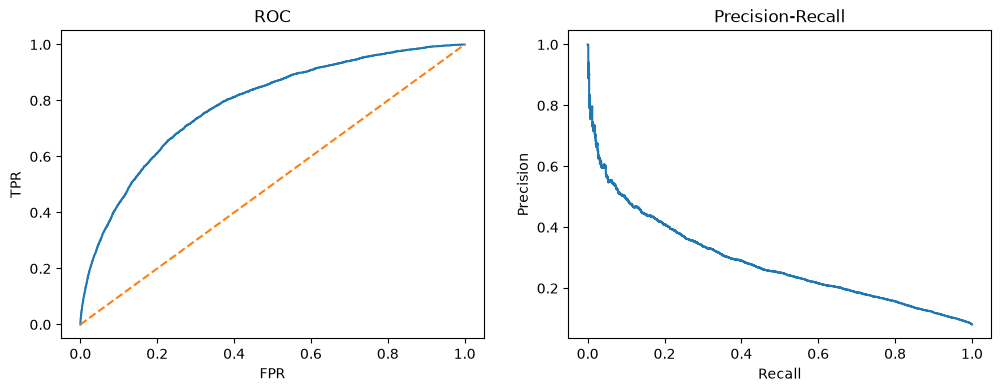

KS = 0.4349


In [3]:
fpr, tpr, _ = roc_curve(y_test, score)
prec, rec, _ = precision_recall_curve(y_test, score)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(fpr, tpr); ax[0].plot([0,1],[0,1],'--'); ax[0].set_title('ROC'); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR')
ax[1].plot(rec, prec); ax[1].set_title('Precision-Recall'); ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
plt.show()
print('KS =', round(np.max(tpr - fpr), 4))

## 3. Threshold de negócio (matriz de custo) e matriz de confusão

Threshold de negócio: 0.47000000000000003
Matriz de confusão [ [TN FP] [FN TP] ]:
 [[41340 15198]
 [ 1489  3476]]
Taxa de aprovação: 69.6%


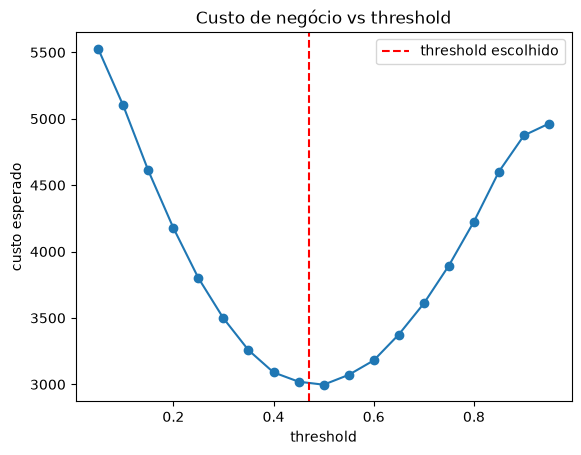

In [4]:
thr = bundle['threshold']
pred = (score >= thr).astype(int)
cm = confusion_matrix(y_test, pred)
print(f'Threshold de negócio: {thr}')
print('Matriz de confusão [ [TN FP] [FN TP] ]:\n', cm)
print(f'Taxa de aprovação: {(score < thr).mean():.1%}')
# Varredura de custo
b = bundle['metrics']['business']
ts = np.linspace(0.05, 0.95, 19)
costs = [b['cost_false_negative']*((score<t)&(y_test==1)).sum() + b['cost_false_positive']*((score>=t)&(y_test==0)).sum() for t in ts]
plt.plot(ts, costs, marker='o'); plt.axvline(thr, color='r', ls='--', label='threshold escolhido')
plt.xlabel('threshold'); plt.ylabel('custo esperado'); plt.legend(); plt.title('Custo de negócio vs threshold'); plt.show()

## 4. Importância de variáveis (LightGBM)

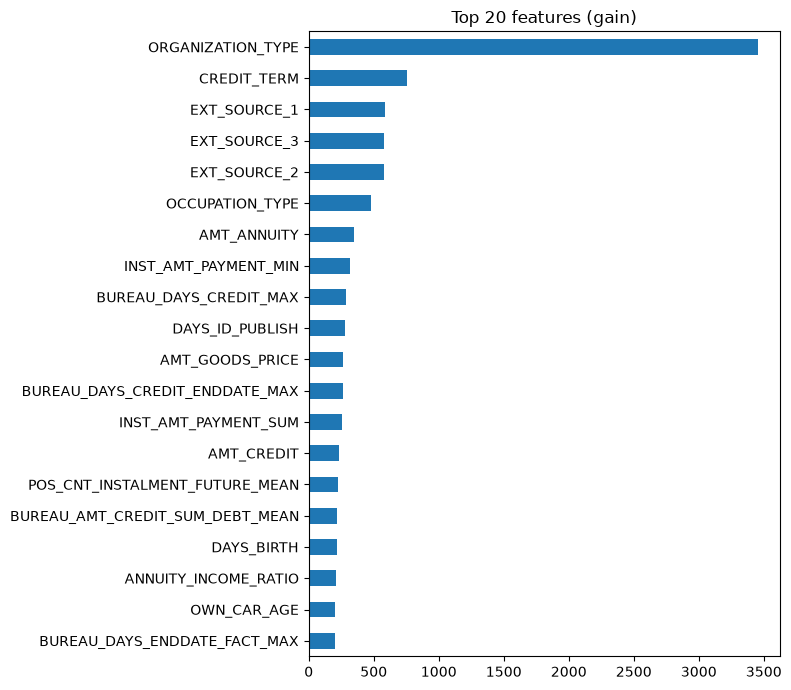

In [5]:
imp = pd.Series(model.feature_importances_, index=bundle['feature_names']).sort_values(ascending=False).head(20)
imp[::-1].plot(kind='barh', figsize=(8, 7), title='Top 20 features (gain)'); plt.tight_layout(); plt.show()

## 5. Explicabilidade — SHAP

SHAP traduz o modelo (caixa-preta) em contribuições por variável — essencial para
**governança de crédito** e defesa na banca.

C:\Users\gsabi\PycharmProjects\fia_tcc\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


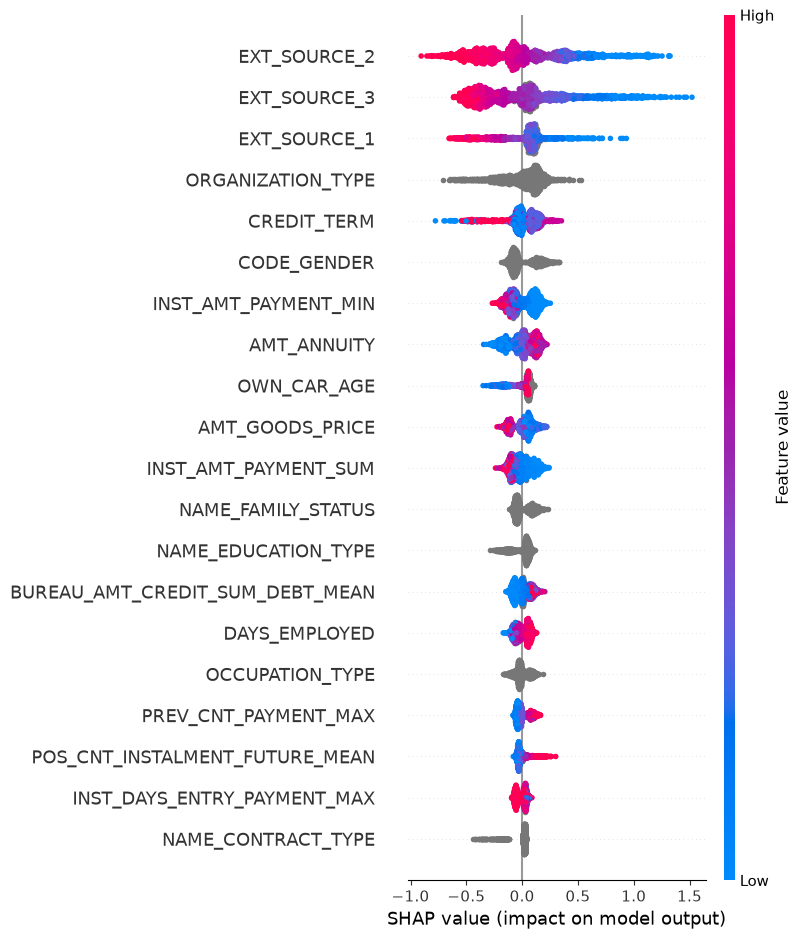

In [6]:
import shap
sample = X_test.sample(2000, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, max_display=20)

## 6. Viés por segmento sensível — gênero e idade

Compara AUC, taxa de aprovação (no threshold de negócio) e taxa de default real entre
subgrupos de `CODE_GENDER` e faixas de `AGE_YEARS`, no conjunto de teste. Objetivo:
descartar discriminação indireta antes de defender o modelo perante a banca.

In [7]:
gender = X_test['CODE_GENDER'].astype(object)
rows = []
for g in sorted(gender.dropna().unique()):
    mask = (gender == g).values
    if mask.sum() < 30:
        continue
    rows.append({
        'grupo': g,
        'n': int(mask.sum()),
        'AUC': round(roc_auc_score(y_test[mask], score[mask]), 4),
        'taxa_aprovacao': round((score[mask] < thr).mean(), 4),
        'taxa_default_real': round(y_test[mask].mean(), 4),
    })
gender_df = pd.DataFrame(rows)
gender_df

,grupo,n,AUC,taxa_aprovacao,taxa_default_real
0,F,40561,0.7783,0.7428,0.0699
1,M,20940,0.7834,0.6064,0.1017


In [8]:
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['<25', '25-35', '35-45', '45-55', '55-65', '65+']
age_group = pd.cut(X_test['AGE_YEARS'], bins=age_bins, labels=age_labels)

rows = []
for a in age_labels:
    mask = (age_group == a).values
    if mask.sum() < 30:
        continue
    rows.append({
        'faixa_etaria': a,
        'n': int(mask.sum()),
        'AUC': round(roc_auc_score(y_test[mask], score[mask]), 4),
        'taxa_aprovacao': round((score[mask] < thr).mean(), 4),
        'taxa_default_real': round(y_test[mask].mean(), 4),
    })
age_df = pd.DataFrame(rows)
age_df

,faixa_etaria,n,AUC,taxa_aprovacao,taxa_default_real
0,<25,2437,0.7392,0.4350,0.1165
1,25-35,14415,0.7816,0.5749,0.1052
2,35-45,16803,0.7871,0.6940,0.0828
3,45-55,14097,0.7900,0.7436,0.0733
4,55-65,12145,0.7438,0.8121,0.0562
5,65+,1606,0.7697,0.9191,0.0349


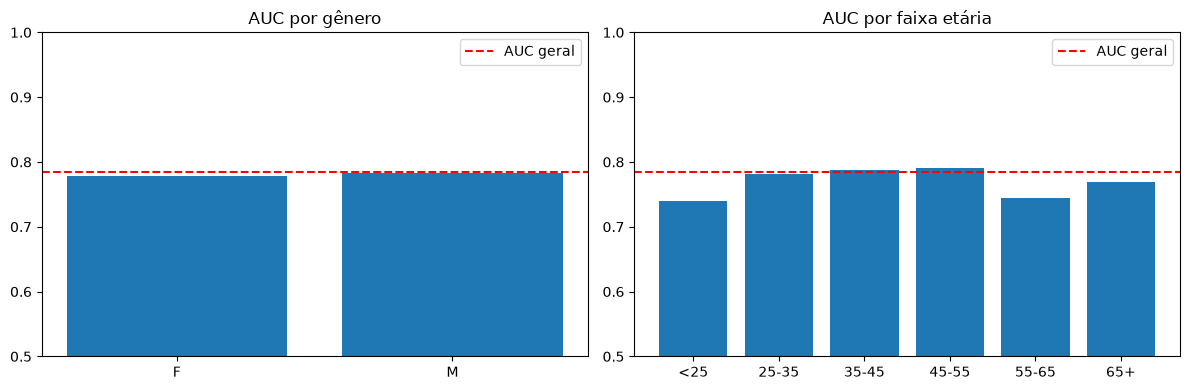

In [9]:
overall_auc = bundle['metrics']['champion']['auc']
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(gender_df['grupo'], gender_df['AUC'])
ax[0].axhline(overall_auc, color='r', ls='--', label='AUC geral')
ax[0].set_title('AUC por gênero'); ax[0].set_ylim(0.5, 1.0); ax[0].legend()
ax[1].bar(age_df['faixa_etaria'], age_df['AUC'])
ax[1].axhline(overall_auc, color='r', ls='--', label='AUC geral')
ax[1].set_title('AUC por faixa etária'); ax[1].set_ylim(0.5, 1.0); ax[1].legend()
plt.tight_layout(); plt.show()

## 7. Desempenho no grupo thin-file (sem histórico de bureau)

Clientes sem nenhum registro em `bureau` (`BUREAU_COUNT` nulo após o merge na ABT) têm
menos sinal disponível. Compara AUC, taxa de aprovação e taxa de default real desse
grupo contra o restante da base.

In [10]:
thin_mask = X_test['BUREAU_COUNT'].isna().values
groups = {'thin-file (sem bureau)': thin_mask, 'com histórico de bureau': ~thin_mask}

rows = []
for label, mask in groups.items():
    rows.append({
        'grupo': label,
        'n': int(mask.sum()),
        'pct_da_base': round(mask.mean(), 4),
        'AUC': round(roc_auc_score(y_test[mask], score[mask]), 4),
        'taxa_aprovacao': round((score[mask] < thr).mean(), 4),
        'taxa_default_real': round(y_test[mask].mean(), 4),
    })
thin_df = pd.DataFrame(rows)
thin_df

,grupo,n,pct_da_base,AUC,taxa_aprovacao,taxa_default_real
0,thin-file (sem bureau),8776,0.1427,0.7733,0.5732,0.1014
1,com histórico de bureau,52727,0.8573,0.7854,0.7169,0.0773


## Diagnóstico crítico (Results / Governança)

- **Overfitting**: controlado — AUC treino 0,883 vs. validação 0,781 vs. teste 0,785.
  O gap treino→validação (~10 p.p.) é esperado num LightGBM com centenas de features,
  mas validação e teste ficam praticamente empatados, indicando boa generalização
  (early stopping na iteração 783).
- **Viés por gênero** (seção 6): AUC muito próximo entre M (0,7834) e F (0,7783) — o
  modelo discrimina risco igualmente bem nos dois grupos. A taxa de aprovação é menor
  para homens (60,6% vs. 74,3%), mas isso acompanha a taxa de default real observada
  (10,2% vs. 7,0%) — a diferença reflete risco real medido nos dados, não um viés
  injustificado do modelo.
- **Viés por idade** (seção 6): AUC cai nos extremos — clientes com menos de 25 anos
  (AUC 0,739) e a faixa 55-65 (AUC 0,744) têm poder de ordenação mais fraco que a faixa
  35-55 (AUC ~0,79). Ponto de atenção: o modelo é menos confiável exatamente para o
  segmento mais jovem, que também tem a maior taxa de default real (11,7%).
- **Thin-file — sem histórico de bureau** (seção 7): 14,3% da base de teste não tem
  nenhum registro em `bureau`. Esse grupo tem AUC menor (0,773 vs. 0,785 do restante) e
  taxa de aprovação mais baixa (57,3% vs. 71,7%), apesar de também ter default real mais
  alto (10,1% vs. 7,7%). Confirma a hipótese: menos sinal disponível → score menos
  confiável para esse segmento.
- **Cenários de falha**: concentrar decisões 100% automáticas nos segmentos com AUC mais
  baixo (jovens <25, thin-file) é o principal risco operacional — recomenda-se rota de
  revisão humana para esses casos (ver `MLOps/Readme.md`, faixa cinza), em vez de
  aprovação/negação totalmente automática.
- **Confiança geral**: AUC ~0,785 + KS ~0,435 dão poder de ordenação suficiente para
  sustentar a régua de decisão; a matriz de custo conecta a métrica técnica ao impacto
  financeiro.
- **Métricas de monitoramento sugeridas**: PSI das features, drift do score, AUC em
  janela móvel, taxa de aprovação e inadimplência observada (back-testing), e AUC
  segmentado por gênero/idade/thin-file recalculado periodicamente.